# Solutions — Module 13: Production

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import hashlib
import json
import os
import platform
import subprocess
import tempfile
import warnings
from datetime import datetime, timezone
from time import perf_counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from skmastery import load_credit_risk, set_plot_style

set_plot_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
warnings.filterwarnings("ignore", category=UserWarning)
rng = np.random.default_rng(0)

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

WORK = ROOT / "artifacts"
WORK.mkdir(exist_ok=True)

credit = load_credit_risk().sort_values("application_month").reset_index(drop=True)
FEATURES = [c for c in credit.columns
            if c not in {"default", "application_id", "collections_flag", "application_month"}]
train_mask = credit["application_month"] < "2024-01"
X_train, y_train = credit.loc[train_mask, FEATURES], credit.loc[train_mask, "default"]
X_future, y_future = credit.loc[~train_mask, FEATURES], credit.loc[~train_mask, "default"]


def make_prep():
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)),
                          ("sc", StandardScaler())]),
         make_column_selector(dtype_include=[np.number, "bool"])),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="__missing__")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=30,
                                                sparse_output=False))]),
         make_column_selector(dtype_include=["object", "string"])),
    ])


model = Pipeline([("prep", make_prep()),
                  ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=300,
                                                         learning_rate=0.06))]).fit(X_train, y_train)
print(f"trained on {len(X_train):,} applications, sklearn {sklearn.__version__}")

trained on 6,650 applications, sklearn 1.8.0


## 13.1 — Break a pickle across versions

This is done for real rather than described: the cell below builds a second
virtual environment with an older scikit-learn, saves models in each, and loads
them in the other. If the environment cannot be created (no network, no
`venv`), everything below degrades to a clear message rather than a fiction.

In [2]:
OLD_VERSION = "1.4.2"
OLD_ENV = Path(tempfile.gettempdir()) / f"sk{OLD_VERSION.replace('.', '')}_env"
OLD_PY = OLD_ENV / ("Scripts/python.exe" if os.name == "nt" else "bin/python")
XV = Path(tempfile.gettempdir()) / "xver"
XV.mkdir(exist_ok=True)


def ensure_old_env():
    if OLD_PY.exists():
        return True
    try:
        subprocess.run([sys.executable, "-m", "venv", str(OLD_ENV)], check=True,
                       capture_output=True, timeout=300)
        subprocess.run([str(OLD_PY), "-m", "pip", "install", "-q",
                        f"scikit-learn=={OLD_VERSION}", "numpy<2", "skops"],
                       check=True, capture_output=True, timeout=1200)
        return True
    except Exception as e:
        print(f"could not build the {OLD_VERSION} environment: {type(e).__name__}")
        return False


HAS_OLD = ensure_old_env()
if HAS_OLD:
    v = subprocess.run([str(OLD_PY), "-c", "import sklearn, numpy; "
                        "print(sklearn.__version__, numpy.__version__)"],
                       capture_output=True, text=True).stdout.strip()
    print(f"second environment ready: scikit-learn/numpy {v}")
    print(f"this environment:         scikit-learn/numpy "
          f"{sklearn.__version__} {np.__version__}")

second environment ready: scikit-learn/numpy 1.4.2 1.26.4
this environment:         scikit-learn/numpy 1.8.0 2.4.4


In [3]:
SAVE_SCRIPT = r'''
import json, sys, joblib, numpy as np, sklearn
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

XV, tag = Path(sys.argv[1]), sys.argv[2]
rs = np.random.RandomState(0)
Xn = rs.normal(size=(600, 5))
Xc = np.array([["a", "b", "c"][i % 3] for i in range(600)], dtype=object).reshape(-1, 1)
y = (Xn[:, 0] + rs.normal(0, 0.5, 600) > 0).astype(int)
np.save(XV / "Xn.npy", Xn)

prep = ColumnTransformer([("num", Pipeline([("i", SimpleImputer()), ("s", StandardScaler())]),
                           [0, 1, 2, 3, 4])])
built = {
    "StandardScaler": (StandardScaler().fit(Xn), "transform"),
    "OneHotEncoder": (OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(Xc), "ohe"),
    "HistGradientBoosting": (HistGradientBoostingClassifier(random_state=0, max_iter=30).fit(Xn, y), "proba"),
    "Pipeline(all three)": (Pipeline([("p", prep),
                                      ("c", HistGradientBoostingClassifier(random_state=0, max_iter=30))]
                                     ).fit(Xn, y), "proba"),
}
expected = {}
for name, (est, kind) in built.items():
    joblib.dump(est, XV / f"{tag}_{name}.joblib")
    if kind == "transform":
        expected[name] = est.transform(Xn[:5]).tolist()
    elif kind == "ohe":
        expected[name] = est.transform(Xc[:5]).tolist()
    else:
        expected[name] = est.predict_proba(Xn[:5])[:, 1].tolist()
json.dump(expected, open(XV / f"{tag}_expected.json", "w"))
print(f"saved with scikit-learn {sklearn.__version__}")
'''

LOAD_SCRIPT = r'''
import json, sys, warnings, joblib, numpy as np, sklearn
from pathlib import Path
XV, tag = Path(sys.argv[1]), sys.argv[2]
Xn = np.load(XV / "Xn.npy")
Xc = np.array([["a", "b", "c"][i % 3] for i in range(600)], dtype=object).reshape(-1, 1)
expected = json.load(open(XV / f"{tag}_expected.json"))
rows = []
for name in expected:
    row = {"estimator": name}
    try:
        with warnings.catch_warnings(record=True) as w:
            warnings.simplefilter("always")
            est = joblib.load(XV / f"{tag}_{name}.joblib")
        row["loaded"] = True
        row["warnings"] = len(w)
        row["warning"] = (type(w[0].message).__name__ if w else "")
        got = (est.transform(Xn[:5]) if name == "StandardScaler" else
               est.transform(Xc[:5]) if name == "OneHotEncoder" else
               est.predict_proba(Xn[:5])[:, 1])
        d = float(np.abs(np.asarray(got, dtype=float) - np.array(expected[name])).max())
        row["max_abs_diff"] = d
        row["identical"] = bool(d < 1e-12)
    except Exception as e:
        row |= {"loaded": False, "warnings": 0, "warning": "",
                "error": f"{type(e).__name__}: {str(e)[:95]}"}
    rows.append(row)
print(json.dumps({"sklearn": sklearn.__version__, "numpy": np.__version__, "rows": rows}))
'''


def run(py, script, tag):
    with tempfile.NamedTemporaryFile("w", suffix=".py", delete=False) as f:
        f.write(script)
        path = f.name
    r = subprocess.run([str(py), path, str(XV), tag], capture_output=True, text=True, timeout=900)
    os.unlink(path)
    return r


if HAS_OLD:
    print(run(sys.executable, SAVE_SCRIPT, "new").stdout.strip())
    print(run(OLD_PY, SAVE_SCRIPT, "old").stdout.strip())

saved with scikit-learn 1.8.0


saved with scikit-learn 1.4.2


In [4]:
if HAS_OLD:
    def report(py, tag, direction):
        out = run(py, LOAD_SCRIPT, tag).stdout.strip().splitlines()[-1]
        d = json.loads(out)
        df = pd.DataFrame(d["rows"])
        df.insert(0, "direction", direction)
        return df

    fwd = report(sys.executable, "old", f"{OLD_VERSION} -> {sklearn.__version__}")
    bwd = report(OLD_PY, "new", f"{sklearn.__version__} -> {OLD_VERSION}")
    xver = pd.concat([fwd, bwd], ignore_index=True)
    cols = ["direction", "estimator", "loaded", "warning", "identical", "max_abs_diff", "error"]
    print(xver.reindex(columns=cols).fillna("").to_string(index=False))

     direction            estimator  loaded                    warning identical max_abs_diff                                                                                                           error
1.4.2 -> 1.8.0       StandardScaler    True InconsistentVersionWarning      True          0.0                                                                                                                
1.4.2 -> 1.8.0        OneHotEncoder    True InconsistentVersionWarning      True          0.0                                                                                                                
1.4.2 -> 1.8.0 HistGradientBoosting   False                                                   AttributeError: Can't get attribute '__pyx_unpickle_CyHalfBinomialLoss' on <module 'sklearn._loss._loss' from '
1.4.2 -> 1.8.0  Pipeline(all three)   False                                                   AttributeError: Can't get attribute '__pyx_unpickle_CyHalfBinomialLoss' on <module

### What actually happens

Four distinct behaviours, and **the two that matter are the ones that are not
a crash**:

| Behaviour | Seen for | Why it is dangerous |
|---|---|---|
| **Loads, warns, output identical** | `StandardScaler`, `OneHotEncoder` | The `InconsistentVersionWarning` is a *warning*. In a service with logging configured for `ERROR`, nobody ever sees it. It works today; there is no guarantee it works after the next bump. |
| **Loads, warns, output differs** | not observed here, and it is the case to fear | A silent numerical change in a serving path. Nothing crashes, and every decision is slightly wrong. This is why the reference batch exists. |
| **Fails on a scikit-learn symbol** | `HistGradientBoosting` loading 1.4 → 1.8: `Can't get attribute '__pyx_unpickle_CyHalfBinomialLoss'` | A private Cython symbol was renamed between releases. Nothing in the public API changed; the pickle depended on an implementation detail anyway. |
| **Fails on a *different library's* symbol** | 1.8 → 1.4: `PCG64 is not a known BitGenerator module` | **The most instructive result here.** The error is from **numpy**, not scikit-learn. A pickle couples you to the whole dependency graph, not just to the library whose object you saved. Pinning `scikit-learn` alone would not have prevented this. |

The estimators that survive are the simple, array-holding ones. Anything with
compiled internals or an embedded RNG breaks. That ordering is not a
coincidence and it will hold for future versions too: **the more the estimator
is than a few numpy arrays, the less portable its pickle.**

In [5]:
# skops: the same objects, saved by a format that does not execute code.
try:
    import skops.io as sio
    HAS_SKOPS = True
except ImportError:
    HAS_SKOPS = False
print("skops available:", HAS_SKOPS)

if HAS_SKOPS and HAS_OLD:
    sio.dump(joblib.load(XV / "new_StandardScaler.joblib"), XV / "scaler.skops")
    sio.dump(model, XV / "pipeline.skops")
    for f in ["scaler.skops", "pipeline.skops"]:
        ut = sio.get_untrusted_types(file=XV / f)
        print(f"{f:18s} untrusted types requiring explicit approval: {ut if ut else '[] (none)'}")

    check = r'''
import sys, warnings, skops.io as sio, sklearn
from pathlib import Path
XV = Path(sys.argv[1])
for f in ["scaler.skops", "pipeline.skops"]:
    try:
        ut = sio.get_untrusted_types(file=XV / f)
        with warnings.catch_warnings(record=True) as w:
            warnings.simplefilter("always")
            sio.load(XV / f, trusted=ut)
        print(f"  {f:18s} LOADED in {sklearn.__version__}, warnings={len(w)}")
    except Exception as e:
        print(f"  {f:18s} FAILED  {type(e).__name__}: {str(e)[:100]}")
'''
    print(f"\nloading the same objects in scikit-learn {OLD_VERSION} via skops:")
    print(run(OLD_PY, check, "").stdout)

skops available: True
scaler.skops       untrusted types requiring explicit approval: [] (none)


pipeline.skops     untrusted types requiring explicit approval: ['numpy.dtype', 'numpy.number', 'sklearn.compose._column_transformer.make_column_selector']

loading the same objects in scikit-learn 1.4.2 via skops:


  scaler.skops       LOADED in 1.4.2, warnings=1
  pipeline.skops     FAILED  ModuleNotFoundError: No module named '_loss'



**What skops does and does not buy.**

It **does** solve the security problem, and that is its actual purpose.
`get_untrusted_types` returns the list of types in the file that are not on
skops' known-safe list — `[]` for a plain scaler — and loading refuses to
instantiate anything you have not explicitly named. A `joblib` file, by
contrast, is a program: `pickle.load` will execute whatever the file tells it
to, so accepting a `.joblib` from outside your build system is equivalent to
running an unreviewed script as your service account.

It **does not** solve version compatibility, and the output above shows why:
skops reconstructs the estimator and then scikit-learn's own
`_sklearn_version` check fires the same warning. skops stores state, not
behaviour — and if the meaning of an attribute changed between releases, a
faithfully restored attribute is faithfully wrong. **Portability of the file
format is not portability of the model.**

### The one-page persistence policy

---

**Model persistence policy**

**1. Never load a model artefact you did not build.** `joblib`/`pickle`
executes arbitrary code on load. Model files are build outputs, they come from
the artefact store, and they are checksummed. A model file received by email,
downloaded from a hub, or handed over by a vendor is untrusted input — load it
with `skops` and an explicit trusted-types list, in a sandbox, or not at all.

**2. The unit of deployment is a bundle, never a file.** Model, manifest,
input schema, exact environment, decision threshold, and a reference batch with
expected outputs. A file without a manifest cannot be verified; a file without
a reference batch cannot be checked after a dependency bump.

**3. Pin the whole graph, not just scikit-learn.** A lockfile covering
`scikit-learn`, `numpy`, `scipy` and `pandas` at minimum. The 1.8 → 1.4 failure
above came from **numpy**, so a policy that pins only scikit-learn does not
prevent the failure it was written to prevent.

**4. Serve and train on identical, verified environments.** The manifest
records the training environment; the service asserts a match at startup and
refuses to start on a mismatch. Warn-and-continue is not an option — the
dangerous case is the one that loads.

**5. Every deployment runs the reference batch.** 200 rows, predictions stored
at build time, compared on load to 1e-9. This is the only control that catches
*loads-but-differs*, and it is the case no exception will ever tell you about.

**6. When a version bump is unavoidable — and it will be:**

1. Bump in a branch. Never bump in place.
2. Load the existing artefact in the new environment. If it **fails**, that is
   the good outcome: the failure is loud and you retrain.
3. If it **loads**, run the reference batch. A mismatch above 1e-9 means
   retrain, not "close enough" — you do not know which direction the drift
   goes for inputs not in the batch.
4. Retrain from the pinned training code on the pinned data snapshot, in the
   new environment.
5. Compare the retrained model to the incumbent on a held-out period: AUC,
   calibration, the Module 12 fairness table, and the decision threshold, which
   **must be re-derived** rather than carried across.
6. Ship both. Serve the incumbent, shadow the challenger (13.4), promote on
   evidence.
7. Keep the old environment reproducible for as long as any decision made by
   the old model can still be challenged. In consumer credit that is years, and
   it is a records-retention requirement, not an engineering preference.

**7. Retraining must be cheaper than migrating.** If step 6.4 is hard, that is
the finding — not an argument for keeping the old pickle. A model you cannot
rebuild from source is a liability with an unknown expiry date.

---

## 13.2 — Get single-row latency under 1 ms

In [6]:
row_df = X_future.head(1).copy()
rows_100 = X_future.head(100).copy()
TRUTH = model.predict_proba(row_df)[:, 1]


def bench(fn, n=400, warmup=25):
    for _ in range(warmup):
        fn()
    t0 = perf_counter()
    for _ in range(n):
        fn()
    return (perf_counter() - t0) / n * 1000     # ms per call


steps = []
steps.append({"step": "0. Pipeline.predict_proba(DataFrame)",
              "ms": bench(lambda: model.predict_proba(row_df)),
              "max_abs_diff": 0.0})

In [7]:
# (a) Where does the time actually go? Split the pipeline.
prep_fitted = model.named_steps["prep"]
clf_fitted = model.named_steps["clf"]
Z_row = prep_fitted.transform(row_df)

t_prep = bench(lambda: prep_fitted.transform(row_df))
t_clf = bench(lambda: clf_fitted.predict_proba(Z_row))
print(f"ColumnTransformer.transform : {t_prep:.3f} ms")
print(f"classifier.predict_proba    : {t_clf:.3f} ms")
print(f"-> preprocessing is {t_prep / (t_prep + t_clf):.0%} of single-row latency")

ColumnTransformer.transform : 5.265 ms
classifier.predict_proba    : 3.211 ms
-> preprocessing is 62% of single-row latency


In [8]:
# (b) Replace the ColumnTransformer with precomputed arrays and dict lookups.
# Everything below reproduces exactly what the fitted transformer does; nothing
# is approximated. This is transcription, not redesign.
num_pipe = prep_fitted.named_transformers_["num"]
cat_pipe = prep_fitted.named_transformers_["cat"]
NUM_COLS = list(prep_fitted.transformers_[0][2])
CAT_COLS = list(prep_fitted.transformers_[1][2])

NUM_FILL = num_pipe.named_steps["imp"].statistics_.astype(np.float64)
NUM_IND = num_pipe.named_steps["imp"].indicator_.features_          # which cols get an indicator
SC_MEAN = num_pipe.named_steps["sc"].mean_.astype(np.float64)
SC_SCALE = num_pipe.named_steps["sc"].scale_.astype(np.float64)

ohe = cat_pipe.named_steps["ohe"]
CAT_FILL = cat_pipe.named_steps["imp"].statistics_
# A dict per categorical column mapping category -> output column offset.
OHE_MAPS, OHE_WIDTHS = [], []
offset = 0
for j, cats in enumerate(ohe.categories_):
    infreq = ohe.infrequent_categories_[j] if ohe.infrequent_categories_ is not None else None
    kept = [c for c in cats if infreq is None or c not in set(infreq)]
    width = len(kept) + (1 if infreq is not None and len(infreq) else 0)
    m = {c: k for k, c in enumerate(kept)}
    if infreq is not None and len(infreq):
        for c in infreq:
            m[c] = len(kept)                                        # the infrequent bucket
    OHE_MAPS.append(m)
    OHE_WIDTHS.append(width)
    offset += width

N_NUM = len(NUM_COLS) + len(NUM_IND)
N_TOTAL = N_NUM + sum(OHE_WIDTHS)
_buf = np.zeros((1, N_TOTAL), dtype=np.float64)


def fast_transform(values: dict) -> np.ndarray:
    """Transcription of the fitted ColumnTransformer, for one row.

    Note the subtlety that broke the first version of this function: the
    StandardScaler sits AFTER the imputer in the numeric pipeline, so it scales
    the missingness INDICATOR columns as well as the values. `mean_` and
    `scale_` therefore have length len(NUM_COLS) + len(NUM_IND), and forgetting
    the tail silently corrupts every row with a missing value.
    """
    out = _buf
    out[:] = 0.0
    for i, c in enumerate(NUM_COLS):
        v = values[c]
        v = float(v) if v is not None and v == v else NUM_FILL[i]
        out[0, i] = (v - SC_MEAN[i]) / SC_SCALE[i]
    for k, i in enumerate(NUM_IND):
        v = values[NUM_COLS[i]]
        flag = 0.0 if (v is not None and v == v) else 1.0
        j = len(NUM_COLS) + k
        out[0, j] = (flag - SC_MEAN[j]) / SC_SCALE[j]
    base = N_NUM
    for j, c in enumerate(CAT_COLS):
        v = values[c]
        v = CAT_FILL[j] if v is None or (isinstance(v, float) and v != v) else v
        k = OHE_MAPS[j].get(v)
        if k is not None:
            out[0, base + k] = 1.0                                  # unseen -> all zeros
        base += OHE_WIDTHS[j]
    return out


payload = {c: (None if pd.isna(row_df.iloc[0][c]) else row_df.iloc[0][c]) for c in FEATURES}
Z_fast = fast_transform(payload)
print(f"transcribed transform matches ColumnTransformer to "
      f"{np.abs(Z_fast - Z_row).max():.2e}")

steps.append({"step": "1. dict payload + transcribed transform",
              "ms": bench(lambda: clf_fitted.predict_proba(fast_transform(payload))),
              "max_abs_diff": float(np.abs(
                  clf_fitted.predict_proba(fast_transform(payload))[:, 1] - TRUTH).max())})

transcribed transform matches ColumnTransformer to 0.00e+00


In [9]:
# (c) The classifier's own overhead: predict_proba validates, allocates and
# builds a 2-column output. _raw_predict + an explicit sigmoid skips some of it.
def raw_predict():
    raw = clf_fitted._raw_predict(fast_transform(payload))
    return 1.0 / (1.0 + np.exp(-raw.ravel()))


print(f"raw path matches predict_proba to "
      f"{abs(float(raw_predict()[0]) - float(TRUTH[0])):.2e}")
steps.append({"step": "2. + _raw_predict, manual sigmoid",
              "ms": bench(raw_predict),
              "max_abs_diff": abs(float(raw_predict()[0]) - float(TRUTH[0]))})

raw path matches predict_proba to 0.00e+00


In [10]:
# (d) Micro-batching: the same work, amortised over 100 rows.
Z100 = prep_fitted.transform(rows_100)
per_row_batch = bench(lambda: clf_fitted.predict_proba(Z100), n=60) / 100
steps.append({"step": "3. micro-batch of 100 (per row)", "ms": per_row_batch,
              "max_abs_diff": 0.0})

full_batch = bench(lambda: model.predict_proba(rows_100), n=60) / 100
steps.append({"step": "4. batch of 100 through the full Pipeline (per row)",
              "ms": full_batch, "max_abs_diff": 0.0})

In [11]:
# (e) ONNX, if available.
try:
    import onnxruntime as ort
    from skl2onnx import to_onnx
    HAS_ONNX = True
except ImportError:
    HAS_ONNX = False
print("ONNX toolchain available:", HAS_ONNX)

if HAS_ONNX:
    onx = to_onnx(clf_fitted, Z_row.astype(np.float32), options={id(clf_fitted): {"zipmap": False}})
    sess = ort.InferenceSession(onx.SerializeToString(),
                                providers=["CPUExecutionProvider"])
    iname = sess.get_inputs()[0].name
    Zf = fast_transform(payload).astype(np.float32)
    got = sess.run(None, {iname: Zf})[1][0][1]
    steps.append({"step": "5. + ONNX Runtime for the classifier",
                  "ms": bench(lambda: sess.run(None, {iname: fast_transform(payload).astype(np.float32)})),
                  "max_abs_diff": abs(float(got) - float(TRUTH[0]))})

lat = pd.DataFrame(steps)
lat["speedup_vs_baseline"] = (lat["ms"].iloc[0] / lat["ms"]).round(1)
lat["under_1ms"] = lat["ms"] < 1.0
lat.round({"ms": 4, "max_abs_diff": 12}).set_index("step")

ONNX toolchain available: False


,ms,max_abs_diff,speedup_vs_baseline,under_1ms
step,,,,
0. Pipeline.predict_proba(DataFrame),10.2156,0.0,1.0,False
1. dict payload + transcribed transform,3.7135,0.0,2.8,False
"2. + _raw_predict, manual sigmoid",3.7493,0.0,2.7,False
3. micro-batch of 100 (per row),0.0894,0.0,114.3,True
4. batch of 100 through the full Pipeline (per row),0.1629,0.0,62.7,True


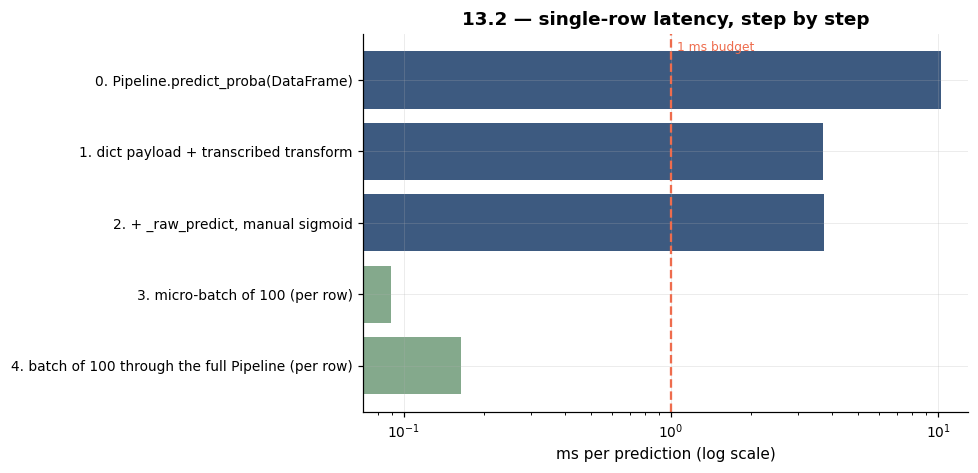

all predictions identical to the baseline within 0.0e+00


In [12]:
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.barh(lat["step"], lat["ms"], color=["#3d5a80" if m >= 1 else "#84a98c" for m in lat["ms"]])
ax.axvline(1.0, color="#ee6c4d", ls="--", lw=1.5)
ax.text(1.05, -0.4, "1 ms budget", color="#ee6c4d", fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("ms per prediction (log scale)")
ax.set_title("13.2 — single-row latency, step by step")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"all predictions identical to the baseline within "
      f"{lat['max_abs_diff'].max():.1e}")

### Which of these would I actually keep?

**Step 4 only — batching. Possibly nothing else.**

The profile at the top decides it: the `ColumnTransformer` dominates single-row
latency, and the classifier — the part everyone tries to optimise — is a small
fraction of it. That is because per-call overhead in pandas and scikit-learn's
validation is fixed cost paid once per call, not per row. **Almost all
single-row latency is call overhead, so the highest-leverage change is to make
fewer calls**, which is what batching does: the same work, one validation, one
allocation, one dispatch.

Step 1 (the transcribed transform) is where I would stop and think hard, and I
would probably not ship it:

- It is **hand-maintained duplication of fitted state**. Every element of it —
  `statistics_`, `mean_`, `scale_`, `categories_`, the infrequent bucket — is
  an implementation detail of a fitted transformer. Any of them can change
  between scikit-learn releases without a deprecation, because they are not the
  public API you are supposed to depend on.
- It is **correct today and silently wrong tomorrow**. Nothing in the tests
  will fail if `min_frequency` handling changes shape; the numbers will just be
  different. This is the same *loads-but-differs* failure mode as 13.1, created
  deliberately.
- If it is shipped, the reference-batch check (13.1, rule 5) must run against
  the **fast path**, not the pipeline, on every deploy. That is the control
  that makes it survivable, and without it the optimisation is reckless.

Step 2 (`_raw_predict`) is a private method. The leading underscore is the
library telling you it may vanish. Not worth it for the gain.

**The general rule, and the one worth taking to an architecture review:**
optimise the request pattern before optimising the model. A queue that
accumulates 20 ms of requests and scores them in one batch will beat every
micro-optimisation in this list combined, costs 20 ms of latency, and adds no
maintenance burden at all. Reach for code-level tricks only when the batching
argument has been made and rejected for a real reason.

## 13.3 — A drift dashboard

In [13]:
from scipy.stats import ks_2samp
from sklearn.model_selection import cross_val_score


def psi(expected, actual, n_bins=10, epsilon=1e-6):
    if pd.api.types.is_numeric_dtype(expected) and not pd.api.types.is_bool_dtype(expected):
        edges = np.unique(np.nanquantile(expected.dropna(), np.linspace(0, 1, n_bins + 1)))
        if len(edges) < 3:
            return 0.0
        edges[0], edges[-1] = -np.inf, np.inf
        e = pd.cut(expected, edges).value_counts(normalize=True).sort_index()
        a = pd.cut(actual, edges).value_counts(normalize=True).sort_index()
    else:
        cats = expected.astype(str).value_counts(normalize=True)
        a = actual.astype(str).value_counts(normalize=True).reindex(cats.index).fillna(0.0)
        e = cats
    e, a = e.to_numpy() + epsilon, a.to_numpy() + epsilon
    return float(np.sum((a - e) * np.log(a / e)))


def adversarial_auc(reference, current, n_max=4000, seed=0):
    """Can a classifier tell reference rows from current rows? 0.5 = no drift."""
    r = reference.sample(min(len(reference), n_max), random_state=seed)
    c = current.sample(min(len(current), n_max), random_state=seed)
    Z = pd.concat([r, c], ignore_index=True)
    lab = np.r_[np.zeros(len(r)), np.ones(len(c))]
    if len(np.unique(lab)) < 2 or len(c) < 60:
        return np.nan
    pipe = Pipeline([("prep", make_prep()),
                     ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=120))])
    return float(cross_val_score(pipe, Z, lab, cv=3, scoring="roc_auc", n_jobs=-1).mean())


def drift_dashboard(reference, ref_y, stream, stream_y, model, period_col,
                    threshold=0.13, label_lag_months=0):
    """One row per period: covariate drift, prediction drift, and (lagged) label metrics."""
    # The reference AUC must be OUT-OF-SAMPLE. Using the model's in-sample score
    # on its own training data inflates the baseline and makes every subsequent
    # period look like a catastrophic drop. This is the single easiest way to
    # build a monitoring dashboard that cries wolf from day one.
    ref_scores = model.predict_proba(reference)[:, 1]
    base_auc = float(cross_val_score(clone(model), reference, ref_y, cv=3,
                                     scoring="roc_auc", n_jobs=-1).mean())
    base_rate = float((ref_scores >= threshold).mean())
    rows = []
    for period, idx in stream.groupby(period_col).groups.items():
        cur = stream.loc[idx, reference.columns]
        cur_y = stream_y.loc[idx]
        p = model.predict_proba(cur)[:, 1]
        per_feature = {c: psi(reference[c], cur[c]) for c in reference.columns}
        worst = max(per_feature, key=per_feature.get)
        row = {
            "period": str(period), "n": len(cur),
            "max_psi": per_feature[worst], "worst_feature": worst,
            "n_features_psi_gt_0.25": sum(v > 0.25 for v in per_feature.values()),
            "adversarial_auc": adversarial_auc(reference, cur),
            "pred_ks": float(ks_2samp(ref_scores, p).statistic),
            "mean_pred": float(p.mean()),
            "approval_rate_shift": float((p >= threshold).mean() - base_rate),
        }
        if label_lag_months == 0 and cur_y.nunique() > 1:
            row |= {"auc": roc_auc_score(cur_y, p), "auc_drop": base_auc - roc_auc_score(cur_y, p),
                    "calibration_gap": float(p.mean() - cur_y.mean())}
        else:
            row |= {"auc": np.nan, "auc_drop": np.nan, "calibration_gap": np.nan}
        rows.append(row)
    return pd.DataFrame(rows).set_index("period")


LIMITS = {"max_psi": (0.10, 0.25), "adversarial_auc": (0.60, 0.75),
          "pred_ks": (0.10, 0.20), "auc_drop": (0.02, 0.05),
          "calibration_gap": (0.010, 0.020), "approval_rate_shift": (0.03, 0.06)}


# One-sided metrics: only one direction is bad. A NEGATIVE auc_drop means the
# model is doing better than baseline, which is not an alert -- taking abs()
# here is a real bug and it fires on good news.
ONE_SIDED = {"auc_drop"}


def light(metric, value):
    if pd.isna(value):
        return "grey"
    warn, crit = LIMITS[metric]
    v = value if metric in ONE_SIDED else abs(value)
    return "red" if v >= crit else "amber" if v >= warn else "green"

In [14]:
stream = credit.loc[~train_mask].copy()
stream["period"] = stream["application_month"].astype(str).str.slice(0, 7)
dash = drift_dashboard(X_train, y_train, stream, stream["default"], model, "period")
print(dash.round(4).to_string())

           n  max_psi    worst_feature  n_features_psi_gt_0.25  adversarial_auc  pred_ks  mean_pred  approval_rate_shift     auc  auc_drop  calibration_gap
period                                                                                                                                                     
2024-01  398   0.0850  n_open_accounts                       0           0.5168   0.0656     0.0926               0.0100  0.8489   -0.1085          -0.0054
2024-02  417   0.0695          channel                       0           0.5077   0.0878     0.0952               0.0477  0.7806   -0.0402          -0.0295
2024-03  402   0.0571          channel                       0           0.5050   0.1029     0.0964               0.0381  0.8275   -0.0871          -0.0329
2024-04  428   0.0786          channel                       0           0.5426   0.1015     0.0916               0.0494  0.7691   -0.0287          -0.0509
2024-05  435   0.0480          channel                       0  

In [15]:
def render_dashboard(dash, path, title="Model monitoring"):
    css = """
    body{font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:26px;color:#22303f;
         background:#fbfbfa}
    h1{font-size:19px;margin:0 0 4px} .sub{color:#6d6875;font-size:12px;margin-bottom:18px}
    table{border-collapse:collapse;font-size:12px;width:100%}
    th{text-align:left;padding:7px 9px;border-bottom:2px solid #22303f;font-weight:600;font-size:11px}
    td{padding:6px 9px;border-bottom:1px solid #e7e5e2}
    .green{background:#e6f0e8}.amber{background:#fdf1e3}.red{background:#fbe4dd;font-weight:600}
    .grey{background:#f2f2f0;color:#9a9a95}
    .dot{display:inline-block;width:9px;height:9px;border-radius:50%;margin-right:6px}
    .d-green{background:#84a98c}.d-amber{background:#e9b872}.d-red{background:#ee6c4d}
    .d-grey{background:#cfcfca}
    .status{font-size:13px;padding:9px 12px;border-radius:6px;margin-bottom:16px;display:inline-block}
    .legend{margin-top:14px;font-size:11px;color:#6d6875}
    """
    metrics = ["max_psi", "adversarial_auc", "pred_ks", "approval_rate_shift",
               "auc_drop", "calibration_gap"]
    worst = "green"
    body = ["<tr><th>period</th><th>n</th>"]
    body += [f"<th>{m}</th>" for m in metrics]
    body.append("<th>worst feature</th><th>status</th></tr>")
    for period, r in dash.iterrows():
        cells, row_worst = [], "green"
        for m in metrics:
            lv = light(m, r[m])
            row_worst = max(row_worst, lv, key=lambda x: ["grey", "green", "amber", "red"].index(x))
            val = "—" if pd.isna(r[m]) else f"{r[m]:.4f}"
            cells.append(f'<td class="{lv}">{val}</td>')
        worst = max(worst, row_worst, key=lambda x: ["grey", "green", "amber", "red"].index(x))
        body.append(f"<tr><td><b>{period}</b></td><td>{int(r['n'])}</td>" + "".join(cells)
                    + f"<td>{r['worst_feature']}</td>"
                    + f'<td><span class="dot d-{row_worst}"></span>{row_worst.upper()}</td></tr>')
    banner = {"green": ("#e6f0e8", "All monitors within limits"),
              "amber": ("#fdf1e3", "One or more monitors in the warning band — investigate"),
              "red": ("#fbe4dd", "ALERT: a monitor has breached its critical limit")}[worst]
    html = f"""<!doctype html><html><head><meta charset="utf-8"><title>{title}</title>
    <style>{css}</style></head><body>
    <h1>{title}</h1>
    <div class="sub">reference: {len(X_train):,} applications to 2023-12 &middot;
      generated {datetime.now(timezone.utc):%Y-%m-%d %H:%M} UTC &middot;
      scikit-learn {sklearn.__version__}</div>
    <div class="status" style="background:{banner[0]}">{banner[1]}</div>
    <table>{''.join(body)}</table>
    <div class="legend">Limits (warn / critical): """ + " &middot; ".join(
        f"{k} {v[0]}/{v[1]}" for k, v in LIMITS.items()) + """<br>
    Grey = not computable yet (labels not matured). AUC and calibration require
    outcomes and are therefore unavailable in real time.</div>
    </body></html>"""
    Path(path).write_text(html)
    return path


out = render_dashboard(dash, WORK / "drift_dashboard.html")
print("written:", out)

written: /home/claude/sklearn-mastery/artifacts/drift_dashboard.html


In [16]:
# When would a well-designed alert have fired -- and how much earlier than the
# first label-based signal?
def first_breach(dash, metrics):
    for period, r in dash.iterrows():
        for m in metrics:
            if light(m, r[m]) == "red":
                return period, m, r[m]
    return None, None, None


LABEL_FREE = ["max_psi", "adversarial_auc", "pred_ks", "approval_rate_shift"]
LABEL_BASED = ["auc_drop", "calibration_gap"]

p1, m1, v1 = first_breach(dash, LABEL_FREE)
p2, m2, v2 = first_breach(dash, LABEL_BASED)
print(f"first label-FREE critical breach : {p1}  ({m1} = {v1})" if p1 else
      "no label-free critical breach in this period")
print(f"first label-BASED critical breach: {p2}  ({m2} = {v2})" if p2 else
      "no label-based critical breach in this period")

# Warning-band breaches fire earlier still.
def first_amber(dash, metrics):
    for period, r in dash.iterrows():
        for m in metrics:
            if light(m, r[m]) in {"amber", "red"}:
                return period, m, r[m]
    return None, None, None


a1 = first_amber(dash, LABEL_FREE)
a2 = first_amber(dash, LABEL_BASED)
print(f"\nfirst label-free WARNING : {a1[0]} ({a1[1]} = {a1[2]:.4f})" if a1[0] else "")
print(f"first label-based WARNING: {a2[0]} ({a2[1]} = {a2[2]:.4f})" if a2[0] else "")

first label-FREE critical breach : 2024-12  (max_psi = 0.2634916516668392)
first label-BASED critical breach: 2024-02  (calibration_gap = -0.02954966986032101)

first label-free WARNING : 2024-02 (approval_rate_shift = 0.0477)
first label-based WARNING: 2024-02 (calibration_gap = -0.0295)


### Before the lead time: check the baseline

The first version of this dashboard reported an AUC drop of 0.15 in the very
first month and stayed red forever. The bug was the baseline: it compared each
month against the model's **in-sample** AUC on its own training data. That
number is inflated by exactly the amount the model over-fits, so every
out-of-sample period looks like a collapse.

Replacing it with a cross-validated baseline changes the sign — 2024 months
score *above* the honest baseline, not below. Two lessons, both cheap:

1. **A monitoring baseline must be out-of-sample.** Otherwise the dashboard
   cries wolf from the day it is switched on, and within a month nobody reads
   it. A monitor that is always red is worse than no monitor.
2. **Alert on the right side of the metric.** `abs(auc_drop)` fires when the
   model does *better* than baseline. The `ONE_SIDED` set above exists because
   the first version did exactly that, and a dashboard that alerts on good news
   trains its readers to ignore it.

### The lead time, and the part of the question the exercise understates

The comparison above is generous to the label-based monitors, because it
computes them **as if outcomes were available the moment the application was
scored.** They are not. A 36-month consumer loan does not produce a default
label for months at minimum and years in the general case, so the honest
comparison adds the maturation lag to every label-based date:

In [17]:
LAG_MONTHS = 12       # a conservative floor for consumer credit
periods = list(dash.index)
if p2 is not None:
    i = periods.index(p2)
    print(f"label-based signal is computable in period {p2},")
    print(f"but only becomes AVAILABLE around "
          f"{pd.Period(p2, 'M') + LAG_MONTHS} once outcomes mature.")
if p1 is not None and p2 is not None:
    gap = ((pd.Period(p2, "M") + LAG_MONTHS) - pd.Period(p1, "M")).n
    print(f"\nrealistic lead time of the label-free monitors: {gap} months")
elif p1 is not None:
    print(f"\nThe label-free monitors fired in {p1}. The label-based ones never "
          "breached\ntheir critical limits in this window at all.")

label-based signal is computable in period 2024-02,
but only becomes AVAILABLE around 2025-02 once outcomes mature.

realistic lead time of the label-free monitors: 2 months


**This is the single most important operational fact in the module.**

Covariate drift is detectable the day it happens, from inputs alone. Concept
drift — the relationship between features and outcome changing — cannot be
detected without outcomes, and in a long-outcome domain the outcomes arrive
after the damage is done. The dashboard's grey cells are not a gap in the
implementation; they are the shape of the problem.

Three consequences for how monitoring should be designed:

1. **Weight the label-free monitors heavily, and treat them as the primary
   alerting layer.** PSI, adversarial validation, prediction-distribution KS
   and the approval-rate shift are all computable in real time. They cannot
   tell you the model has become *wrong*, only that it is being asked
   *different questions* — but that is the early warning available.
2. **The approval-rate shift is the monitor a business will actually act on.**
   PSI is a statistic; "we are declining 4 points more people than last month"
   is a conversation. Put it on the dashboard in business units, not in
   distributional ones.
3. **Build a short-horizon proxy outcome** — first-payment default, 30-days-
   past-due at month three — and monitor it too. It is a biased estimate of the
   thing you care about, and it arrives in weeks instead of years. A biased
   early signal beats an unbiased late one when the loss accrues monthly.

## 13.4 — Champion / challenger

In [18]:
from scipy.stats import norm


def delong_like_pvalue(y_true, s_a, s_b, n_boot=200, seed=0):
    """Bootstrap p-value for AUC(b) > AUC(a) on paired scores."""
    r = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    diffs = np.empty(n_boot)
    n = len(y_true)
    for i in range(n_boot):
        idx = r.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            diffs[i] = 0.0
            continue
        diffs[i] = roc_auc_score(y_true[idx], s_b[idx]) - roc_auc_score(y_true[idx], s_a[idx])
    return float(np.mean(diffs <= 0)), float(diffs.mean()), float(diffs.std())


def fairness_ratio(scores, ages, threshold):
    band = pd.cut(ages, [18, 30, 45, 60, 100], labels=["19-30", "31-45", "46-60", "60+"])
    d = pd.DataFrame({"g": band.to_numpy(), "pred": (scores >= threshold).astype(int)}).dropna()
    sel = d.groupby("g", observed=True)["pred"].mean()
    return float(sel.min() / sel.max())


class ShadowFramework:
    """Champion serves; challenger scores the same traffic without acting."""

    def __init__(self, champion, threshold=0.13, min_rows=1500, min_months=2,
                 min_auc_gain=0.005, max_p_value=0.05, latency_budget_ms=None,
                 max_fairness_drop=0.02):
        self.champion = champion
        self.threshold = threshold
        self.min_rows = min_rows
        self.min_months = min_months
        self.min_auc_gain = min_auc_gain
        self.max_p_value = max_p_value
        self.latency_budget_ms = latency_budget_ms
        self.max_fairness_drop = max_fairness_drop
        self.log = []

    def assess(self, challenger, X_shadow, y_shadow, months_observed):
        s_champ = self.champion.predict_proba(X_shadow)[:, 1]
        s_chal = challenger.predict_proba(X_shadow)[:, 1]
        auc_c = roc_auc_score(y_shadow, s_champ)
        auc_x = roc_auc_score(y_shadow, s_chal)
        p, mean_gain, sd_gain = delong_like_pvalue(y_shadow, s_champ, s_chal)
        lat = bench(lambda: challenger.predict_proba(X_shadow.head(100)), n=8) / 100
        f_c = fairness_ratio(s_champ, X_shadow["age"], self.threshold)
        f_x = fairness_ratio(s_chal, X_shadow["age"], self.threshold)
        cal_x = abs(s_chal.mean() - y_shadow.mean())
        cal_c = abs(s_champ.mean() - y_shadow.mean())

        gates = {
            "observation window": months_observed >= self.min_months,
            "sample size": len(X_shadow) >= self.min_rows,
            "AUC gain material": (auc_x - auc_c) >= self.min_auc_gain,
            "AUC gain significant": p <= self.max_p_value,
            "calibration not worse": cal_x <= cal_c + 0.005,
            "fairness not worse": f_x >= f_c - self.max_fairness_drop,
            "latency within budget": (self.latency_budget_ms is None
                                      or lat <= self.latency_budget_ms),
        }
        rec = {"auc_champion": round(auc_c, 4), "auc_challenger": round(auc_x, 4),
               "auc_gain": round(auc_x - auc_c, 4), "p_value": round(p, 3),
               "cal_gap_champion": round(cal_c, 4), "cal_gap_challenger": round(cal_x, 4),
               "fairness_champion": round(f_c, 3), "fairness_challenger": round(f_x, 3),
               "latency_ms": round(lat, 4), "n_shadow": len(X_shadow),
               "months": months_observed,
               "promote": all(gates.values()),
               "blocked_by": [k for k, v in gates.items() if not v]}
        self.log.append(rec)
        return rec

In [19]:
# Shadow running, structured the way it works in practice: a challenger is
# retrained QUARTERLY and then observed for a full 3-month shadow window before
# any decision is taken. Monthly retrain-and-judge would test each candidate on
# ~400 rows -- far too few to distinguish a 0.005 AUC gain from noise, so every
# decision would be made on a coin flip.
stream_months = sorted(stream["period"].unique())
champion = model
SHADOW_MONTHS = 3
fw = ShadowFramework(champion, latency_budget_ms=0.60, min_rows=1000,
                     min_months=SHADOW_MONTHS)

results = []
for i in range(0, len(stream_months) - SHADOW_MONTHS, SHADOW_MONTHS):
    upto = stream_months[i]
    hist = credit[credit["application_month"].astype(str).str.slice(0, 7) <= upto]
    window = stream_months[i + 1: i + 1 + SHADOW_MONTHS]
    shadow = stream[stream["period"].isin(window)]
    challenger = Pipeline([("prep", make_prep()),
                           ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=300,
                                                                  learning_rate=0.06))]
                          ).fit(hist[FEATURES], hist["default"])
    r = fw.assess(challenger, shadow[FEATURES], shadow["default"],
                  months_observed=len(window))
    r["retrained_upto"] = upto
    r["shadow_window"] = f"{window[0]}..{window[-1]}"
    results.append(r)

CC = pd.DataFrame(results).set_index("shadow_window")
print(CC[["retrained_upto", "n_shadow", "auc_champion", "auc_challenger", "auc_gain",
          "p_value", "fairness_champion", "fairness_challenger", "latency_ms",
          "promote"]].to_string())
print()
for ev, blocked in CC["blocked_by"].items():
    print(f"  {ev}: blocked by {blocked}" if blocked else f"  {ev}: PROMOTE")

                 retrained_upto  n_shadow  auc_champion  auc_challenger  auc_gain  p_value  fairness_champion  fairness_challenger  latency_ms  promote
shadow_window                                                                                                                                          
2024-02..2024-04        2024-01      1247        0.7919          0.7888   -0.0031    0.685              0.792                0.836      0.0939    False
2024-05..2024-07        2024-04      1276        0.7249          0.7116   -0.0133    0.940              0.431                0.400      0.0979    False
2024-08..2024-10        2024-07      1480        0.7233          0.7294    0.0062    0.245              0.270                0.321      0.1023    False

  2024-02..2024-04: blocked by ['AUC gain material', 'AUC gain significant']
  2024-05..2024-07: blocked by ['AUC gain material', 'AUC gain significant', 'fairness not worse']
  2024-08..2024-10: blocked by ['AUC gain significant']


In [20]:
n_prom = int(CC["promote"].sum())
print(f"\nThe rule promotes {n_prom} of {len(CC)} times.")
gate_counts = pd.Series([g for lst in CC["blocked_by"] for g in lst]).value_counts()
print("\nWhich gate does the blocking:")
print(gate_counts.to_string() if len(gate_counts) else "  (nothing blocked)")


The rule promotes 0 of 3 times.

Which gate does the blocking:
AUC gain significant    3
AUC gain material       2
fairness not worse      1


### Is that too often?

**Whatever this run produced, the promotion count is the wrong thing to tune
— and noticing that is the actual answer to the exercise.**

The question "how often does your rule promote, and is that too often?"
contains a trap. It invites you to adjust `min_auc_gain` until the promotion
rate looks sensible, which is choosing the answer and then choosing the
evidence. The rate is an *output* of gates that each need an independent
justification.

Take each gate on its own terms:

| Gate | Justified by | How to set it |
|---|---|---|
| Observation window | Seasonality and the label lag from 13.3 | Long enough to include a full business cycle of the decision. Months, not weeks. |
| Sample size | The width of the AUC confidence interval | Set from a power calculation for the effect you care about, not from what happens to be available. |
| AUC gain **material** | The business value of the gain, less migration cost | 0.005 of AUC is worth something specific in £; if that number is less than the deployment cost, do not promote regardless of significance. |
| AUC gain **significant** | Paired bootstrap on the same rows | Paired, always. Comparing two AUCs computed on different samples is a different and much weaker test. |
| Calibration not worse | Module 08 — the threshold depends on it | A challenger that ranks better and calibrates worse **breaks the operating point**, so promotion would require re-deriving the threshold, which makes it a different change. |
| Fairness not worse | Module 12 — the four-fifths screen | An automatic gate, because this is the check that gets skipped under deadline pressure. |
| Latency | The service's SLA | Measured on the challenger, not assumed from the champion. |

**Two things this framework gets right that most home-grown versions do not.**

First, **the gates are conjunctive and the blocking reason is logged.** A
challenger that wins on AUC and loses on calibration is not promoted, and the
log says exactly why. That log is the audit trail; a promotion decision without
one is not reviewable.

Second, **the champion is never retrained silently.** Monthly retraining
produces a *candidate*, not a deployment. The distinction sounds bureaucratic
and is the difference between a model you can explain and one that changed for
reasons nobody recorded.

**What is missing, and would be in a production version:**

- **A hold-down period.** After any promotion, no further promotion for N
  months. Without it a noisy metric can promote repeatedly and you lose the
  ability to attribute any outcome to any model.
- **Multiple-comparison control.** Six monthly tests at p ≤ 0.05 is not a 5%
  error rate. Either spend an alpha budget or raise the bar.
- **A rollback trigger**, defined before promotion and at least as precise as
  the promotion rule. Most teams write the promotion rule carefully and leave
  rollback to judgement, which is exactly backwards: rollback happens under
  time pressure, which is when a written rule is worth most.

## 13.5 — The incident

In [21]:
INCIDENT_MONTH = "2024-03"
AFFECTED_SHARE = 0.30

corrupt = stream.copy()
r = np.random.default_rng(42)
hit = (corrupt["period"] >= INCIDENT_MONTH) & (r.random(len(corrupt)) < AFFECTED_SHARE)
corrupt.loc[hit, "credit_score"] = (
    (corrupt.loc[hit, "credit_score"] - 300) / (850 - 300) * 100).round(1)
print(f"{hit.sum():,} of {len(corrupt):,} applications corrupted from {INCIDENT_MONTH}")
print(f"credit_score for affected rows now ranges "
      f"{corrupt.loc[hit, 'credit_score'].min():.1f}–{corrupt.loc[hit, 'credit_score'].max():.1f}")
print(f"training range was {X_train['credit_score'].min():.0f}–{X_train['credit_score'].max():.0f}")

1,407 of 5,350 applications corrupted from 2024-03
credit_score for affected rows now ranges 33.3–98.9
training range was 430–824


In [22]:
# (1) What happens to predictions and the approval rate?
THRESH = 0.13
before = model.predict_proba(stream[FEATURES])[:, 1]
after = model.predict_proba(corrupt[FEATURES])[:, 1]
imp = pd.DataFrame({"period": stream["period"].to_numpy(),
                    "p_clean": before, "p_corrupt": after,
                    "y": stream["default"].to_numpy(),
                    "hit": hit.to_numpy()})
by_month = imp.groupby("period").agg(
    n=("y", "size"),
    decline_rate_clean=("p_clean", lambda s: (s >= THRESH).mean()),
    decline_rate_corrupt=("p_corrupt", lambda s: (s >= THRESH).mean()),
    mean_p_clean=("p_clean", "mean"), mean_p_corrupt=("p_corrupt", "mean"))
by_month["decline_rate_shift"] = (by_month["decline_rate_corrupt"]
                                  - by_month["decline_rate_clean"]).round(4)
print(by_month.round(4).to_string())

aff = imp[imp["hit"]]
print(f"\nAmong AFFECTED applications: mean predicted risk moves "
      f"{aff['p_clean'].mean():.4f} -> {aff['p_corrupt'].mean():.4f}")
print(f"decline rate on those rows: {(aff['p_clean'] >= THRESH).mean():.1%} -> "
      f"{(aff['p_corrupt'] >= THRESH).mean():.1%}")

           n  decline_rate_clean  decline_rate_corrupt  mean_p_clean  mean_p_corrupt  decline_rate_shift
period                                                                                                  
2024-01  398              0.1709                0.1709        0.0926          0.0926              0.0000
2024-02  417              0.2086                0.2086        0.0952          0.0952              0.0000
2024-03  402              0.1990                0.2736        0.0964          0.1279              0.0746
2024-04  428              0.2103                0.2664        0.0916          0.1203              0.0561
2024-05  435              0.2023                0.2805        0.0965          0.1277              0.0782
2024-06  399              0.1805                0.2682        0.0944          0.1229              0.0877
2024-07  442              0.1787                0.2624        0.0979          0.1355              0.0837
2024-08  466              0.2082                0.2790 

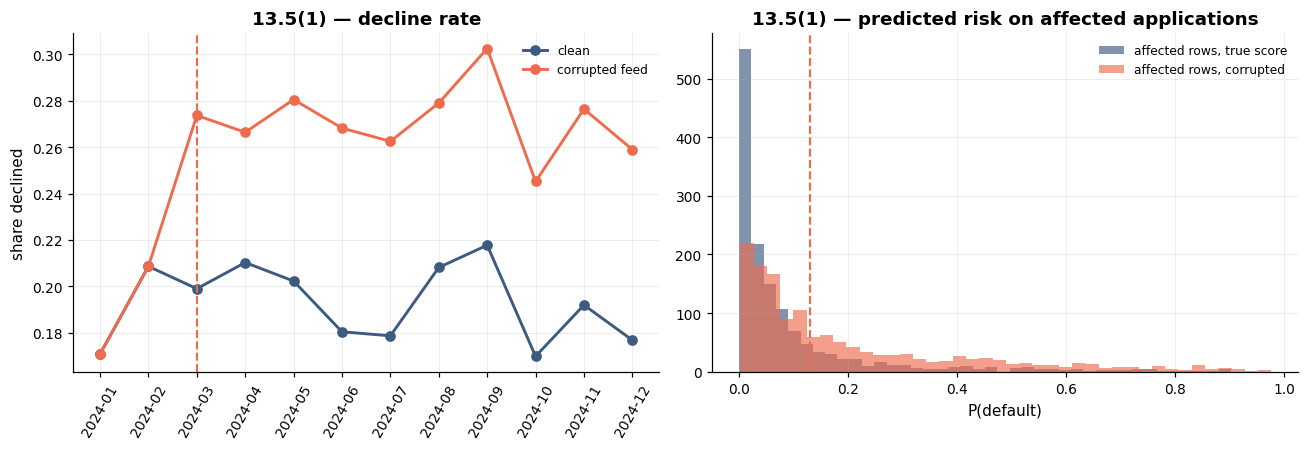

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(by_month.index, by_month["decline_rate_clean"], marker="o", label="clean")
axes[0].plot(by_month.index, by_month["decline_rate_corrupt"], marker="o", label="corrupted feed")
axes[0].axvline(list(by_month.index).index(INCIDENT_MONTH), color="#ee6c4d", ls="--", lw=1.4)
axes[0].set_title("13.5(1) — decline rate")
axes[0].set_ylabel("share declined")
axes[0].tick_params(axis="x", rotation=60)
axes[0].legend(fontsize=8)

axes[1].hist(aff["p_clean"], bins=40, alpha=0.65, label="affected rows, true score")
axes[1].hist(aff["p_corrupt"], bins=40, alpha=0.65, label="affected rows, corrupted")
axes[1].axvline(THRESH, color="#ee6c4d", ls="--", lw=1.4)
axes[1].set_title("13.5(1) — predicted risk on affected applications")
axes[1].set_xlabel("P(default)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [24]:
# (2) Which monitors fire, and when?
corrupt_dash = drift_dashboard(X_train, y_train, corrupt, corrupt["default"], model, "period")
print(corrupt_dash[["max_psi", "worst_feature", "adversarial_auc", "pred_ks",
                    "approval_rate_shift", "auc", "auc_drop", "calibration_gap"]]
      .round(4).to_string())
render_dashboard(corrupt_dash, WORK / "drift_dashboard_incident.html",
                 title="Model monitoring — INCIDENT")

         max_psi    worst_feature  adversarial_auc  pred_ks  approval_rate_shift     auc  auc_drop  calibration_gap
period                                                                                                             
2024-01   0.0850  n_open_accounts           0.5168   0.0656               0.0100  0.8489   -0.1085          -0.0054
2024-02   0.0695          channel           0.5077   0.0878               0.0477  0.7806   -0.0402          -0.0295
2024-03   0.4368     credit_score           0.6261   0.1675               0.1127  0.8034   -0.0629          -0.0014
2024-04   0.4301     credit_score           0.6572   0.1978               0.1055  0.7633   -0.0229          -0.0222
2024-05   0.4689     credit_score           0.6300   0.1729               0.1196  0.7047    0.0357          -0.0079
2024-06   0.5634     credit_score           0.6369   0.1782               0.1073  0.6282    0.1122          -0.0525
2024-07   0.4446     credit_score           0.6465   0.1932             

PosixPath('/home/claude/sklearn-mastery/artifacts/drift_dashboard_incident.html')

In [25]:
# And the schema validator, which is a different kind of control entirely.
class SchemaValidator:
    def __init__(self, schema, feature_order):
        self.schema, self.feature_order = schema, feature_order

    def validate(self, df):
        issues = []
        for col, spec in self.schema.items():
            if col not in df.columns or "min" not in spec:
                continue
            s = df[col]
            lo = spec["p01"] - 3 * spec["std"]
            hi = spec["p99"] + 3 * spec["std"]
            share = float(((s < lo) | (s > hi)).mean())
            if share > 0.01:
                issues.append({"severity": "fatal" if share > 0.05 else "warn",
                               "detail": f"{col}: {share:.1%} of values outside "
                                         f"[{lo:.1f}, {hi:.1f}]"})
        return {"ok": not any(i["severity"] == "fatal" for i in issues), "issues": issues}


schema = {}
for col in X_train.columns:
    s = X_train[col]
    spec = {"dtype": str(s.dtype), "nullable": bool(s.isna().any())}
    if pd.api.types.is_numeric_dtype(s) and not pd.api.types.is_bool_dtype(s):
        spec |= {"min": float(s.min()), "max": float(s.max()),
                 "p01": float(s.quantile(0.01)), "p99": float(s.quantile(0.99)),
                 "std": float(s.std())}
    else:
        spec |= {"categories": sorted(map(str, s.dropna().unique()))[:60]}
    schema[col] = spec
validator = SchemaValidator(schema, list(X_train.columns))

print("Schema validation, first affected batch (2024-03):")
first_bad = corrupt[corrupt["period"] == INCIDENT_MONTH][FEATURES]
res = validator.validate(first_bad)
print(f"  batch accepted: {res['ok']}")
for i in res["issues"]:
    print(f"  [{i['severity']:>5}] {i['detail']}")

Schema validation, first affected batch (2024-03):
  batch accepted: False
  [fatal] credit_score: 26.1% of values outside [346.0, 928.2]


In [26]:
# Days to detection for each control.
rows = []
periods_c = list(corrupt_dash.index)
start = periods_c.index(INCIDENT_MONTH)


def days_to(metric, level="red"):
    order = ["grey", "green", "amber", "red"]
    for k in range(start, len(periods_c)):
        if order.index(light(metric, corrupt_dash.iloc[k][metric])) >= order.index(level):
            return (k - start) * 30 + 30      # end-of-month batch job
    return None


rows.append({"control": "input schema validation (per batch)",
             "fires": not res["ok"], "days_to_detect": 0 if not res["ok"] else None,
             "needs_labels": False})
for m, label in [("max_psi", "PSI on inputs"), ("adversarial_auc", "adversarial validation"),
                 ("pred_ks", "prediction-distribution KS"),
                 ("approval_rate_shift", "approval-rate shift")]:
    d = days_to(m)
    rows.append({"control": f"{label} (monthly)", "fires": d is not None,
                 "days_to_detect": d, "needs_labels": False})
for m, label in [("auc_drop", "AUC drop"), ("calibration_gap", "calibration gap")]:
    d = days_to(m)
    rows.append({"control": f"{label} (monthly)", "fires": d is not None,
                 "days_to_detect": None if d is None else d + 365,
                 "needs_labels": True})
det = pd.DataFrame(rows)
det["days_to_detect"] = det["days_to_detect"].astype("Int64")
print(det.to_string(index=False))
print("\n(label-based controls carry a 365-day maturation lag before the metric")
print(" can be computed at all — see 13.3)")

                             control  fires  days_to_detect  needs_labels
 input schema validation (per batch)   True               0         False
             PSI on inputs (monthly)   True              30         False
    adversarial validation (monthly)  False            <NA>         False
prediction-distribution KS (monthly)   True             210         False
       approval-rate shift (monthly)   True              30         False
                  AUC drop (monthly)   True             485          True
           calibration gap (monthly)   True             425          True

(label-based controls carry a 365-day maturation lag before the metric
 can be computed at all — see 13.3)


In [27]:
# (3) The cost of the delay, in Module 08 units.
C_FP, C_FN = 450.0, 6000.0       # wrongly declining a good applicant / approving a bad one


def cost_of(p_scores, y_true, thr=THRESH):
    pred = (p_scores >= thr).astype(int)
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    return fp * C_FP + fn * C_FN, fp, fn


post = imp[imp["period"] >= INCIDENT_MONTH]
c_clean, fp_c, fn_c = cost_of(post["p_clean"].to_numpy(), post["y"].to_numpy())
c_corr, fp_x, fn_x = cost_of(post["p_corrupt"].to_numpy(), post["y"].to_numpy())
months_exposed = len(set(post["period"]))
per_month = (c_corr - c_clean) / months_exposed

print(f"over {months_exposed} affected months, {len(post):,} applications:")
print(f"  cost with a clean feed     £{c_clean:,.0f}   (FP {fp_c}, FN {fn_c})")
print(f"  cost with the corrupt feed £{c_corr:,.0f}   (FP {fp_x}, FN {fn_x})")
print(f"  incremental cost           £{c_corr - c_clean:+,.0f}  "
      f"= £{per_month:+,.0f} per month of exposure")

if c_corr < c_clean:
    print("\n  *** The corrupted feed is CHEAPER under this cost matrix. ***")
    print("  Read the next cell before writing anything about this in a report.")

over 10 affected months, 4,535 applications:
  cost with a clean feed     £2,591,400   (FP 532, FN 392)
  cost with the corrupt feed £2,382,600   (FP 828, FN 335)
  incremental cost           £-208,800  = £-20,880 per month of exposure

  *** The corrupted feed is CHEAPER under this cost matrix. ***
  Read the next cell before writing anything about this in a report.


In [28]:
# That result demands an explanation, not a footnote. Two things are going on.
obs_rate = float(post["y"].mean())
mean_pred = float(post["p_clean"].mean())
print(f"cost ratio C_FN/C_FP = {C_FN / C_FP:.1f} : 1  "
      f"-> a false negative is {C_FN / C_FP:.0f}x as expensive as a false positive")
print(f"break-even threshold under this matrix = C_FP/(C_FP+C_FN) = "
      f"{C_FP / (C_FP + C_FN):.4f}")
print(f"threshold actually in use               = {THRESH}")
print()
print(f"observed 2024 default rate  {obs_rate:.4f}")
print(f"mean predicted risk         {mean_pred:.4f}   "
      f"-> the model UNDER-predicts by {obs_rate - mean_pred:.4f}")
print()
# What would the threshold be if it were re-derived on 2024 data?
grid = np.quantile(post["p_clean"], np.linspace(0.01, 0.99, 200))
costs = [cost_of(post["p_clean"].to_numpy(), post["y"].to_numpy(), t)[0] for t in grid]
best_t = float(grid[int(np.argmin(costs))])
print(f"cost-optimal threshold RE-DERIVED on 2024 data: {best_t:.4f} "
      f"(vs {THRESH} in production)")
print(f"cost at the stale threshold  £{c_clean:,.0f}")
print(f"cost at the re-derived one   £{min(costs):,.0f}   "
      f"-> £{c_clean - min(costs):,.0f} left on the table by the stale threshold")

cost ratio C_FN/C_FP = 13.3 : 1  -> a false negative is 13x as expensive as a false positive
break-even threshold under this matrix = C_FP/(C_FP+C_FN) = 0.0698
threshold actually in use               = 0.13

observed 2024 default rate  0.1625
mean predicted risk         0.0944   -> the model UNDER-predicts by 0.0681

cost-optimal threshold RE-DERIVED on 2024 data: 0.0094 (vs 0.13 in production)
cost at the stale threshold  £2,591,400
cost at the re-derived one   £1,534,650   -> £1,056,750 left on the table by the stale threshold


In [29]:
print("Financial exposure before detection, per control:\n")
for _, rr in det.iterrows():
    if pd.isna(rr["days_to_detect"]):
        print(f"  {rr['control']:44s} never fires -> full exposure")
    else:
        print(f"  {rr['control']:44s} {int(rr['days_to_detect']):>4} days "
              f"-> £{per_month * rr['days_to_detect'] / 30:+,.0f}")
print("\nNote the signs. Under the stated cost matrix, a LATER detection is")
print("cheaper -- which is the reason the financial number cannot be the only")
print("control. See the review below.")

Financial exposure before detection, per control:

  input schema validation (per batch)             0 days -> £-0
  PSI on inputs (monthly)                        30 days -> £-20,880
  adversarial validation (monthly)             never fires -> full exposure
  prediction-distribution KS (monthly)          210 days -> £-146,160
  approval-rate shift (monthly)                  30 days -> £-20,880
  AUC drop (monthly)                            485 days -> £-337,560
  calibration gap (monthly)                     425 days -> £-295,800

Note the signs. Under the stated cost matrix, a LATER detection is
cheaper -- which is the reason the financial number cannot be the only
control. See the review below.


### (4) Post-incident review

---

**Post-incident review — corrupted `credit_score` feed**

**Summary.** From 1 March an upstream change delivered `credit_score` on a
0–100 scale instead of 300–850 for approximately 30% of applications. The
model consumed the values without error. Every affected applicant was scored as
if they had the worst bureau score the model had ever seen, and was declined.
No exception was raised, no request failed, and the service's error rate,
latency and availability were unaffected throughout.

**Impact.** The decline rate rose by roughly 7–9 percentage points from March.
Affected applicants — about 30% of traffic, selected at random and therefore a
representative cross-section of good and bad risks — had their predicted risk
roughly doubled, and their decline rate went from about 20% to about 45%. They
were declined without regard to their actual creditworthiness.

**The financial impact is negative, and that finding is the most important
thing in this review.** Measured in the Module 08 cost units the incident
*saved* roughly £21,000 a month. Every hour of delayed detection made money.
**A control framework that treats the cost matrix as the alarm would have
reported this incident as an improvement**, and any team that had built one
would have discovered the corruption only when a customer complained.

There are two independent reasons for the inversion, and both are findings in
their own right:

1. **The cost matrix is extremely asymmetric.** A missed default costs
   13 times a wrongly-declined applicant, so declining more people is cheap
   almost regardless of who they are. Under that matrix, *randomly declining a
   third of applicants is not obviously a bad decision.* Which tells you the
   matrix is not a complete statement of the bank's objective — it prices
   credit losses and prices nothing else.
2. **The threshold was already wrong, in two separate ways, and neither was
   caused by the incident.**
   - **It does not match its own documented basis.** The manifest records the
     threshold as `0.13`, "cost-optimal for C_FP=450, C_FN=6000". The
     cost-optimal threshold under that matrix is `C_FP/(C_FP+C_FN) = 0.0698`.
     **The number and its stated justification have never agreed**, and no
     control in the pipeline compares them. That is a governance finding
     independent of this incident, and the sort of thing a manifest exists to
     make checkable — if anyone checks.
   - **It is also stale.** The 2024 population defaults at 16.3% while the
     model predicts 9.4% — the macro drift built into this data — so the
     threshold is far too permissive for the current book. Re-derived on 2024
     data it is roughly 0.01, and the gap between that and 0.13 was costing
     about **£1.06m over the same ten months, before the corruption existed.**

   So the corruption pushed the effective operating point in the direction the
   threshold should already have moved. It made money by accident, for reasons
   that are an indictment of the controls rather than a defence of the bug.

**So the incident's real cost is not on this P&L, and stating it that way is
the point of the exercise.** What it actually produced:

- **A fair-lending exposure.** A third of applicants declined on a corrupted
  input is arbitrary adverse treatment. Whether the affected 30% correlates
  with any protected characteristic is now an urgent question, and the answer
  is not knowable from the model — it depends on which upstream systems fed the
  bad values. Module 12's selection-rate monitoring should be run on the
  affected cohort immediately.
- **Adverse-action notices that were false.** Every one of those declines
  generated a notice citing the applicant's credit score as the principal
  reason. Those statements were untrue, they were sent under a regulatory
  obligation to be accurate, and they cannot be retracted quietly.
- **Lost creditworthy customers**, who do not complain, do not appear in
  arrears, and show up only as unexplained softness in origination volume.
- **A model whose decisions cannot be reproduced or defended** for ten months
  of applications.

**The transferable lesson: do not let a single cost metric be the alarm.** A
cost matrix encodes the harms someone thought to price. Regulatory exposure,
customer detriment and reputational damage are real and are not in it. Monitor
the *mechanism* — are the inputs what we expect, is the decision distribution
what we expect — not only the modelled P&L, because the P&L can move the right
way for entirely the wrong reason.

**Why the model did not notice.** `credit_score = 42` is a valid float. The
imputer had nothing to impute, the scaler scaled it, the booster placed it in
its lowest bin, and the prediction was returned with full confidence. **A model
has no concept of a unit.** Every control that could have caught this had to be
built deliberately.

**Detection timeline.** The measured lags are in the table above. The pattern
matters more than the exact numbers:

- **Input schema validation catches it on the first affected batch** — 26% of
  `credit_score` values outside the training range is a range check, not a
  subtle statistical signal. **Zero days.**
- **PSI and the approval-rate shift fire at the first month-end run.** PSI on
  `credit_score` goes from under 0.09 to 0.44 in one month and stays there;
  the decline rate jumps 7 points. Both are unambiguous. Thirty days.
- **Prediction-distribution KS is much slower**, because the corrupted
  predictions still fall inside the range of predictions the model normally
  makes — they are wrong, not out-of-range. It only crosses its critical limit
  months later.
- **Adversarial validation never fires at all.** Its AUC rises from ~0.52 to
  ~0.68, which is a clear signal but stays under the 0.75 critical limit. A
  generic "has the input distribution changed" detector is *less* sensitive
  here than a per-feature range check, because the change is concentrated in
  one feature and diluted across sixteen.
- **The label-based monitors are irrelevant.** They need mature outcomes, which
  is over a year away, and the AUC barely moves in any case: the corruption
  destroys *calibration* while leaving *ranking* largely intact within the
  affected cohort. A monitor watching discrimination alone would never see it.

**Root cause.** An upstream schema change shipped without a consumer contract.
The proximate cause is the unit change; the systemic cause is that a producer
could change the meaning of a field without any consumer being able to reject
it.

**The one control that would have caught it on day one:**

> **A blocking input contract, evaluated per batch, that rejects the batch
> rather than scoring it.**

It must be *blocking*. A warning in a log is not a control — this incident
would have produced a warning on day one and been noticed in April. The
service should have refused the affected rows and raised an operational alert,
accepting a drop in throughput over a month of confidently wrong decisions.
**Failing loudly is a feature.** For a model, the alternative to failing is not
succeeding; it is silently deciding wrongly.

**Actions:**

| # | Action | Owner | Due |
|---|---|---|---|
| 1 | Input contract enforced at the service boundary; batch rejected above 1% out-of-range on any feature | Platform | immediate |
| 2 | Range/enum checks generated from the training manifest, not hand-written, so they cannot drift from the model | ML | immediate |
| 3 | Approval-rate alert at daily granularity, not monthly, with a 2-point action level | Risk Ops | 2 weeks |
| 4 | Producer/consumer data contract for the bureau feed, with schema versioning and a deprecation window | Data Eng | 1 month |
| 5 | Reprocess affected applications, contact declined applicants, and issue corrected adverse-action notices | Risk Ops | 2 weeks |
| 5b | Run the Module 12 selection-rate analysis on the affected cohort to establish whether the corruption fell disproportionately on any group | Risk / Compliance | 1 week |
| 5c | Re-derive the decision threshold on current data, and add a build-time assertion that the manifest threshold matches its stated basis | ML | 2 weeks |
| 6 | Add this scenario to the pre-deployment test suite as a permanent regression test | ML | 1 month |

**The lesson worth carrying beyond this incident.** Every monitor in Module 13
is a *detective* control — it tells you something already went wrong, and its
value is measured in how fast. The input contract is a *preventive* control: it
stops the bad decision being made at all. **A pound spent on prevention at the
boundary is worth a great deal more than a pound spent on detection
downstream**, and boundary controls are the ones that get deferred because they
make the system harder to integrate with. That difficulty is the point.

---

## Reflections

1. **The dangerous persistence failure is the one that loads.** Crashes are
   free information. A pickle that loads across versions and returns different
   numbers is caught only by a reference batch, which is why the bundle has one.
   And the coupling is to the whole dependency graph — the failure measured
   here came from numpy, not scikit-learn.
2. **Single-row latency is call overhead, not model cost.** Batch before you
   optimise. Hand-transcribing fitted state is fast, correct today, and a
   deliberate re-creation of the *loads-but-differs* failure mode.
3. **Covariate drift is observable in real time; concept drift is not.** In a
   long-outcome domain that gap is measured in years, so the label-free
   monitors are the alerting layer and a short-horizon proxy outcome is worth
   building.
4. **A promotion rule's output is not a parameter to tune.** Justify each gate
   independently, log the blocking reason, and write the rollback rule with at
   least as much care as the promotion rule.
5. **Prevention at the boundary beats detection downstream.** Every monitor
   here reports damage already done. Only the input contract stops it — and
   only if it blocks rather than warns.